# Import data as dataframes

In [1]:
import pandas as pd
import numpy as np
import os

acsdata_path = "../data/processed/"

spectra_A_df = pd.read_csv(os.path.join(acsdata_path,"acs_a_clean_df.csv"), index_col="index")
spectra_A_df = spectra_A_df[spectra_A_df["preprocessing"] == "raw"]
spectra_S_df = pd.read_csv(os.path.join(acsdata_path,"acs_s_clean_df.csv"), index_col="index")
spectra_S_df = spectra_S_df[spectra_S_df["preprocessing"] == "raw"]

labdata_path = "../data/raw/3_laboratory_measurements"

lab_data = pd.read_csv(os.path.join(labdata_path, "sample_s01-s24.csv"))
lab_data["tss_mg_l"] = lab_data["ss_04u_mg_l"] + lab_data["ss_14u_mg_l"]
metadata = pd.read_csv(os.path.join(labdata_path, "sample_metadata.csv"))
lab_data = metadata.merge(lab_data)

spectra_A_df = lab_data.merge(spectra_A_df)
spectra_S_df = lab_data.merge(spectra_S_df)

sp_cols_A = spectra_A_df.columns[23:]
wav_A = np.array(sp_cols_A.astype("float"))

sp_cols_S = spectra_S_df.columns[23:]
wav_S = np.array(sp_cols_S.astype("float"))

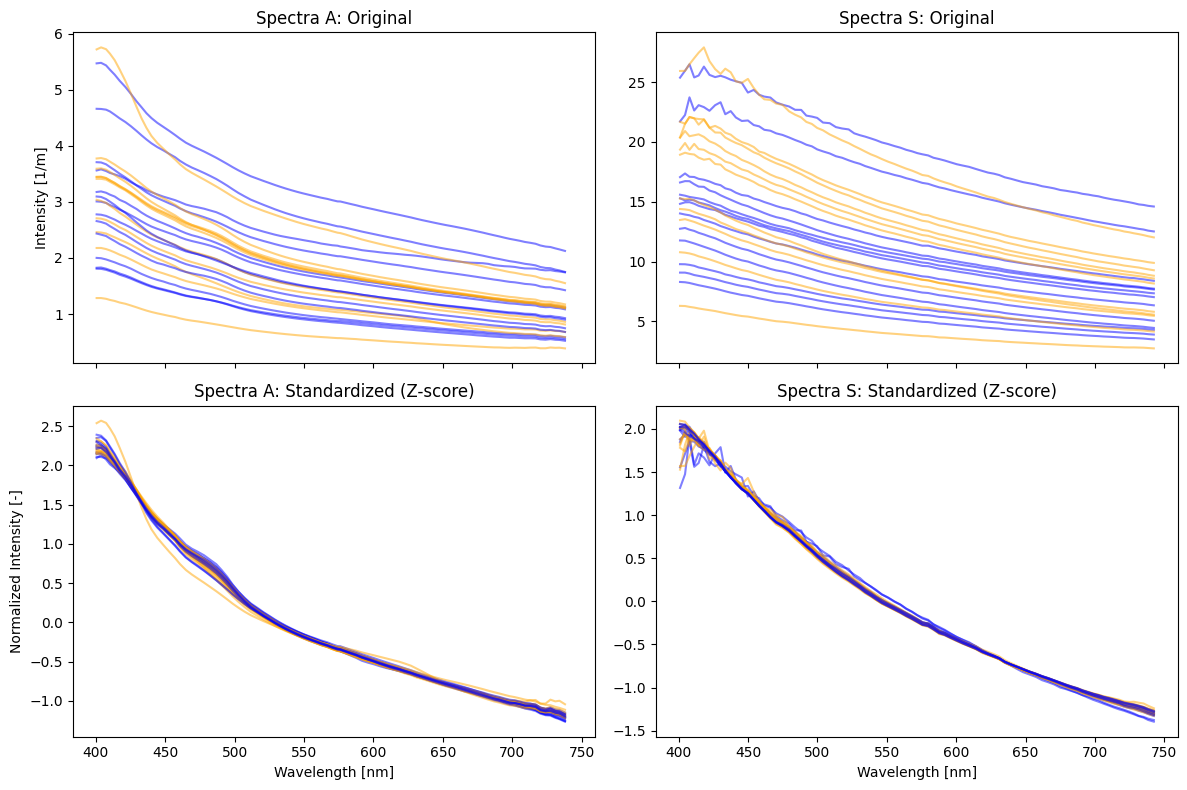

In [4]:
import matplotlib.pyplot as plt

colors_dict = {
    "wet": "blue", 
    "dry": "orange"
}

fig, ax = plt.subplots(ncols=2, nrows=2, sharex=True, figsize = (12, 8))


for (i, sample_data) in spectra_A_df.iterrows():
    sp = sample_data[sp_cols_A]
    color = colors_dict[sample_data["weather"]]
    ax[0, 0].plot(wav_A, sp, color=color, alpha=0.5)
    
    norm_sp = (sp-sp.mean())/sp.std()
    ax[1, 0].plot(wav_A, norm_sp, color=color, alpha=0.5)
    
for (i, sample_data) in spectra_S_df.iterrows():
    sp = sample_data[sp_cols_S]
    color = colors_dict[sample_data["weather"]]
    ax[0, 1].plot(wav_S, sp, color=color, alpha=0.5)
    
    norm_sp = (sp-sp.mean())/sp.std()
    ax[1, 1].plot(wav_S, norm_sp, color=color, alpha=0.5)

# Adding Titles
ax[0, 0].set_title("Spectra A: Original")
ax[0, 1].set_title("Spectra S: Original")
ax[1, 0].set_title("Spectra A: Standardized (Z-score)")
ax[1, 1].set_title("Spectra S: Standardized (Z-score)")

# Adding Y-labels (Left side applies to the whole row usually, or label both)
ax[0, 0].set_ylabel("Intensity [1/m]")
ax[1, 0].set_ylabel("Normalized Intensity [-]")

# Adding X-labels (Bottom row only since sharex=True)
ax[1, 0].set_xlabel("Wavelength [nm]")
ax[1, 1].set_xlabel("Wavelength [nm]")

# Improve spacing between subplots
plt.tight_layout()
plt.show()

# PCA of SNV processed spectra, looking at PC1 and PC2 as a function of the plant

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Isolate spectral data from metadata
# Use columns from 23 onwards as features
X = spectra_A_df.iloc[:, 23:].values
y = spectra_A_df['weather']

# 2. SNV Preprocessing: Focuses on "Shape" 
# Formula: (x - mean(x)) / std(x) for each individual spectrum
X_snv = (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)

# 3. Standard Scaling (across features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_snv)

# 4. Perform PCA
pca = PCA(n_components=5)
pca_result = pca.fit_transform(X_scaled)

# Create result dataframe for plotting
pca_df = pd.DataFrame(data=pca_result, columns=[f'PC{i+1}' for i in range(5)])
pca_df['weather'] = y.values

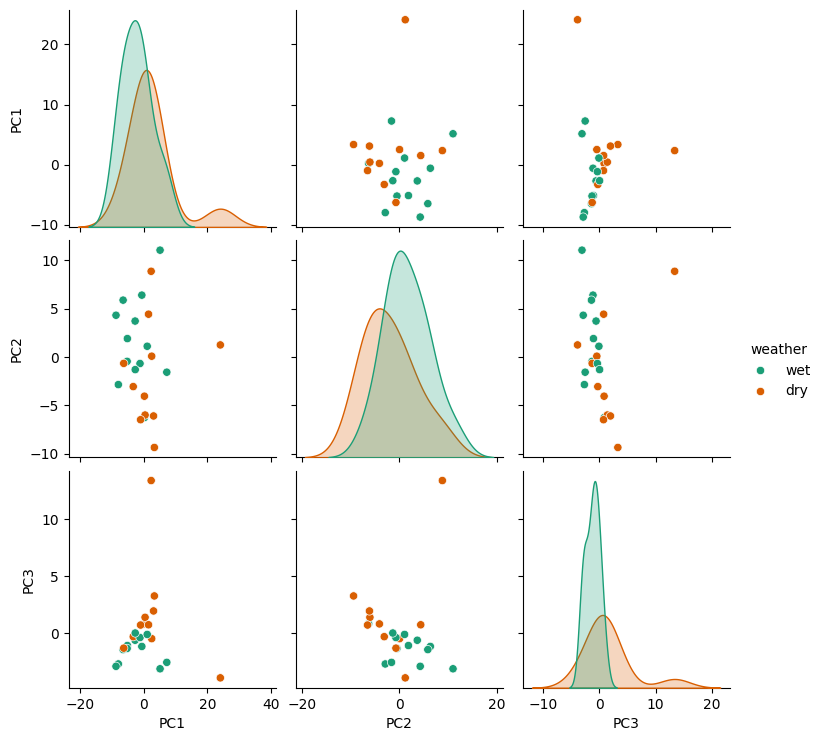

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Isolate spectral data based on your specific dataframe structure
# Columns 23 onwards are your wavelengths
X = spectra_A_df.iloc[:, 23:].values
y = spectra_A_df['weather']

# 2. Preprocessing: Standard Normal Variate (SNV)
# This centers and scales each row independently to focus purely on spectral shape.
X_snv = (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)

# 3. Standardization (Scaling across features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_snv)

# Create a DF with the first 4 or 5 PCs
pca_full = PCA(n_components=4)
X_pca_full = pca_full.fit_transform(X_scaled)
pca_df_full = pd.DataFrame(X_pca_full, columns=[f'PC{i+1}' for i in range(4)])
pca_df_full['weather'] = y.values

# Generate a pairplot for the first 4 PCs
sns.pairplot(pca_df_full, vars=['PC1', 'PC2', 'PC3'], hue='weather', palette='Dark2', diag_kind='kde')
plt.show()

In [10]:

import plotly.express as px


# 1. Use the PCA results you already calculated (X_pca_full)
# We will create a clean dataframe for the interactive plot
df_3d = pd.DataFrame(X_pca_full[:, :3], columns=['PC1', 'PC2', 'PC3'])
df_3d['weather'] = y.values

# 2. Create the 3D Scatter Plot
fig = px.scatter_3d(
    df_3d, 
    x='PC1', 
    y='PC2', 
    z='PC3',
    color='weather',
    symbol='weather', # Different shapes for different plants
    opacity=0.7,
    title='Interactive 3D PCA: Wastewater Spectra Comparison',
    labels={
        'PC1': f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)',
        'PC2': f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)',
        'PC3': f'PC3 ({pca_full.explained_variance_ratio_[2]*100:.1f}%)'
    }
)

# 3. Enhance the layout
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=40),
    legend=dict(yanchor="top", y=0.9, xanchor="left", x=0.1)
)

# Show the plot
fig.show()

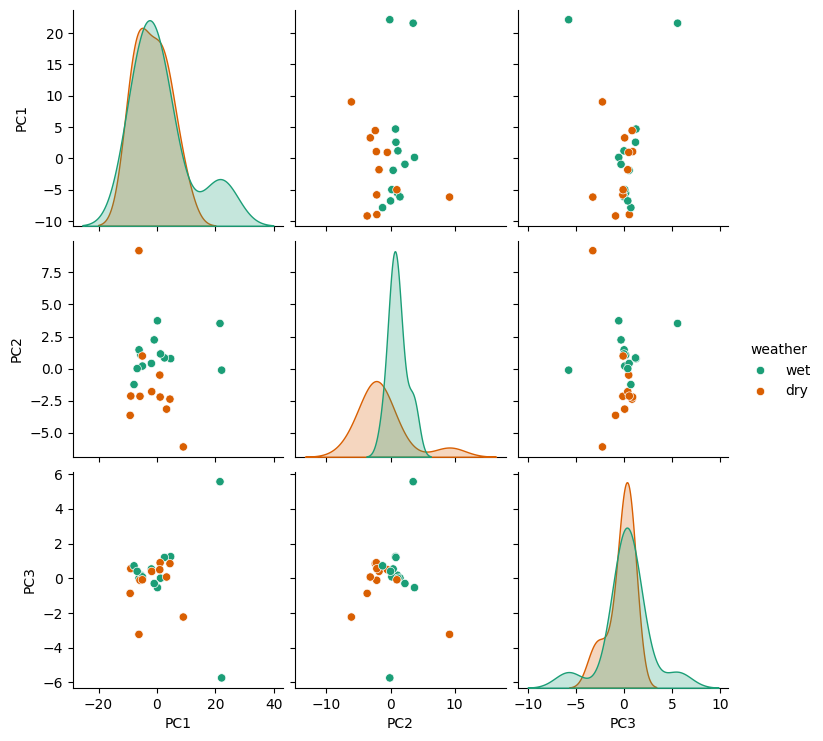

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Isolate spectral data based on your specific dataframe structure
# Columns 23 onwards are your wavelengths
X = spectra_S_df.iloc[:, 23:].values
y = spectra_S_df['weather']

# 2. Preprocessing: Standard Normal Variate (SNV)
# This centers and scales each row independently to focus purely on spectral shape.
X_snv = (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)

# 3. Standardization (Scaling across features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_snv)

# Create a DF with the first 4 or 5 PCs
pca_full = PCA(n_components=4)
X_pca_full = pca_full.fit_transform(X_scaled)
pca_df_full = pd.DataFrame(X_pca_full, columns=[f'PC{i+1}' for i in range(4)])
pca_df_full['weather'] = y.values

# Generate a pairplot for the first 4 PCs
sns.pairplot(pca_df_full, vars=['PC1', 'PC2', 'PC3'], hue='weather', palette='Dark2', diag_kind='kde')
plt.show()

In [12]:

import plotly.express as px


# 1. Use the PCA results you already calculated (X_pca_full)
# We will create a clean dataframe for the interactive plot
df_3d = pd.DataFrame(X_pca_full[:, :3], columns=['PC1', 'PC2', 'PC3'])
df_3d['weather'] = y.values

# 2. Create the 3D Scatter Plot
fig = px.scatter_3d(
    df_3d, 
    x='PC1', 
    y='PC2', 
    z='PC3',
    color='weather',
    symbol='weather', # Different shapes for different plants
    opacity=0.7,
    title='Interactive 3D PCA: Wastewater Spectra Comparison',
    labels={
        'PC1': f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)',
        'PC2': f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)',
        'PC3': f'PC3 ({pca_full.explained_variance_ratio_[2]*100:.1f}%)'
    }
)

# 3. Enhance the layout
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=40),
    legend=dict(yanchor="top", y=0.9, xanchor="left", x=0.1)
)

# Show the plot
fig.show()